In [1]:
import sys
from pathlib import Path

import polars as pl
import torch
from torchvision.transforms import v2 as transforms

this_path = Path(__file__) if '__file__' in globals() else Path("<undefined>.ipynb").resolve()
work_path = next((p for p in this_path.parents if p.name == "research"), None)
tools_path = work_path / Path("../torch-tools")
sys.path.append(str(tools_path))

ee_tools_path_p = work_path / Path("ee")
sys.path.append(str(ee_tools_path_p))

import utils
import pl_utils
from datasets import fetch_handler
from ee_tools.ee_refiner import EERefiner
from network import Network, Networks
from exp_manager import ExpManager
from torchvision import models
from analyzer import Analyzer


In [2]:
pl_utils.Config()
exp_path = this_path.parent
exp_mgr = ExpManager(exp_path=exp_path)

df = exp_mgr.fetch_results(refresh=False)
df = df.filter(pl.col("optimizer") == "AdamW")
df = df.filter(pl.col("epochs") == pl.col("epoch").list.last())
df = df.filter(pl.col("model_arc") == "resnet18")
# df = df.filter(pl.col("train_ndata").is_in([100, 500, 1000, ]))
df = df.filter(pl.col("div").is_in([1, 32]))

print(df)

shape: (16, 41)
┌───────────────────────────┬───────────┬────────────────┬──────────────┬─────────────┬───────────────────────────┬───────────────────────────┬─────────────┬───────────┬────────┬────────┬──────┬────────────┬─────────────┬─────────────┬───────┬─────────────────┬─────────────────┬─────┬───────────┬──────────┬────────────┬──────────────────┬───────────┬───────────────────┬─────────────────┬─────────────────┬───────────────────────────┬───────────────────────────┬───────────────────────────┬───────────────────────────┬──────────────────────────┬───────────────────────────┬───────────────────────────┬───────────────────────────┬───────────────────────────┬───────────────────────────┬───────────────────────────┬───────────────────────────┬───────────────────────────┬───────────────────────────┐
│ run_id                    ┆ model_arc ┆ train_dataset  ┆ val_dataset  ┆ num_classes ┆ train_trans               ┆ val_trans                 ┆ train_ndata ┆ val_ndata ┆ epochs ┆ max_l

In [3]:
runs_data = df.to_dicts()

ds_root = work_path / "assets/datasets/"
base_train_ds = fetch_handler(ds_root, "cifar100_train")
base_val_ds = fetch_handler(ds_root, "cifar100_test")
# base_val_ds = fetch_handler(ds_root, "cifar100_train")

val_trans = [transforms.ToImage(), transforms.ToDtype(torch.float32, scale=True), base_train_ds.normalizer()]
val_ds = base_val_ds.transform(val_trans)
val_dl = val_ds.loader(batch_size=128)


In [4]:
# runs_data = runs_data[:1]
for run_data in runs_data:
    run_mgr = exp_mgr.get_run(run_data["run_id"])
    sd = torch.load(run_mgr.fpath("state_dict.pt"))

    net_cls = getattr(models, run_data["model_arc"])
    num_classes = run_data["num_classes"]
    div = run_data["div"]

    network = Network(EERefiner(net_cls(num_classes=num_classes)).cifar_style().multi_narrow(div=div, agg="mean").init_weights().build())
    # network.load_state_dict_flexible(sd)

    results = (
        Analyzer(network)
            .calc_activation_rate(key="activation_rate", layer_pattern=r".*relu.*", with_avg=True, with_layer=True, with_path=True, with_layer_path=True, with_counts=True)
            .calc_channel_survival_rate(key="channel_survival_rate", layer_pattern=r".*relu.*", with_avg=True, with_layer=True, with_path=True, with_layer_path=True, with_counts=True)
            .calc_magnitude(key="magnitude", layer_pattern=r".*relu.*", threshold=1e-6, with_avg=True, with_layer=True, with_path=True, with_layer_path=True, with_counts=True)
            .calc_linear_cka(key="linear_cka", layer_pattern=r".*conv.*", channels=16, with_avg=True, with_layer=True, with_group_info=True)
            # .calc_linear_cka(key="linear_cka", layer_pattern=r".*conv.*", groups=8, with_avg=True, with_layer=True, with_group_info=True)
            # .calc_linear_cka(key="linear_cka", layer_pattern=r".*conv.*", groups=4*div, with_avg=True, with_layer=True, with_group_info=True)
            .calc_eval(key="eval", with_ens=True, with_path=True, with_oracle=True, cumulative_modes=["original", "acc_desc", "acc_asc"])
            # .calc_eval(key="eval", with_ens=True, with_path=True, with_oracle=True, cumulative_modes=["original", "loss_asc", "loss_desc", "acc_desc", "acc_asc"])
            .flow(val_dl)
    )
    
    
    run_data |= results

    # run_mgr.log_param("fire_rate", avg)
    # run_mgr.sync()
    # torch.save(layer_rates, run_mgr.fpath("layer_rates.pt"))
    # torch.save(layer_neurons, run_mgr.fpath("layer_neurons.pt"))

    # print(avg)
    # print(layer_rates)
    # print(layer_neurons)
# exp_mgr.ref_results()


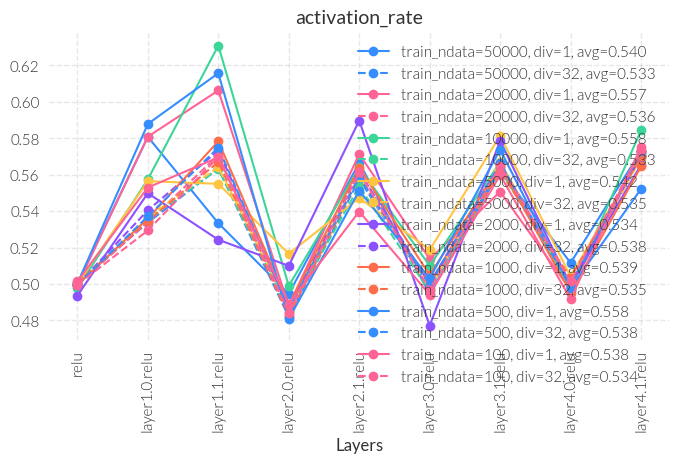

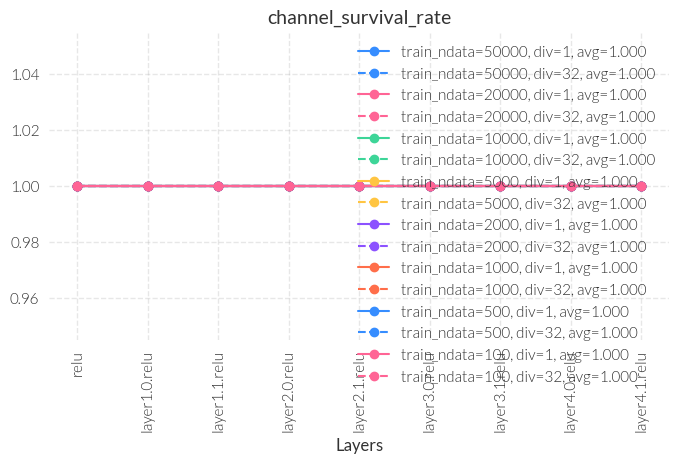

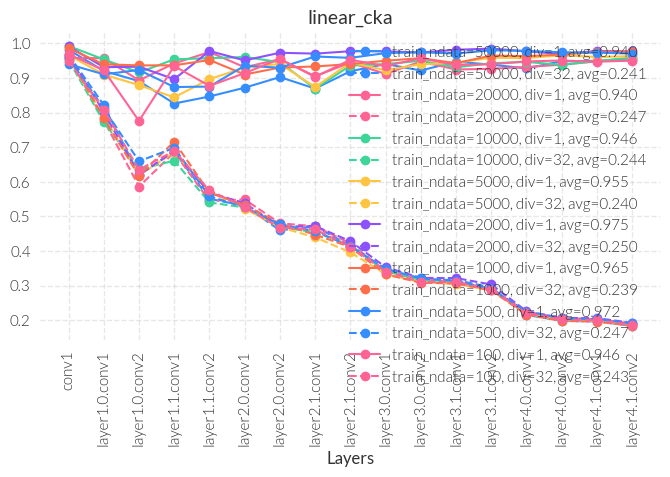

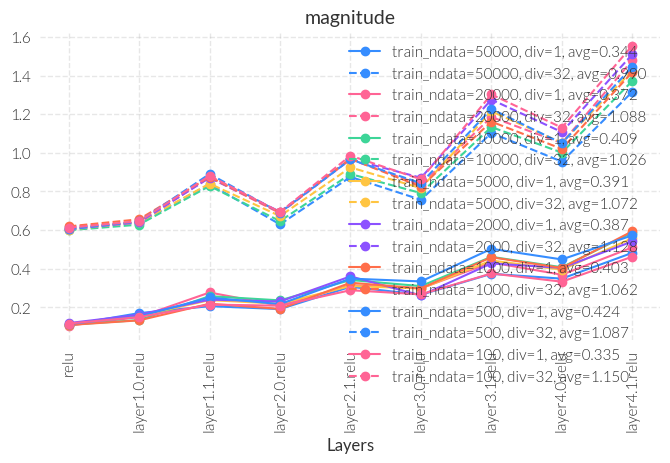

In [5]:
import matplotlib.pyplot as plt
plt.style.use(f'{this_path.parent}/common.mplstyle')
plt.style.use(f'{this_path.parent}/line.mplstyle')

NAME_SLICE = slice(17, None) 

metrics_info = [
    ("activation_rate", "layer"),
    ("channel_survival_rate", "layer"),
    ("linear_cka", "layer"),
    ("magnitude", "layer")
]

# 1つ目が色、2つ目が線種に対応します
lines = ["train_ndata", "div"] 

# 利用可能なスタイルと色のリスト
available_linestyles = ['-', '--', '-.', ':', (0, (3, 1, 1, 1)), (0, (1, 1))]
available_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

for key, idx in metrics_info:
    fig, ax = plt.subplots(figsize=(8, 4))

    # 値とスタイル/色のマッピングを保持する辞書とインデックスを初期化
    linestyle_map = {}
    style_idx = 0
    color_map = {}
    color_idx = 0

    first_data = runs_data[0][key][idx]
    common_layers = list(first_data.keys())
    short_labels = [name[NAME_SLICE] for name in common_layers]
    
    for run_data in runs_data:
        # 平均値(index 0) と 層別データ(index=idx) の取得
        avg_val = run_data[key]["avg"]
        data_dict = run_data[key][idx]
        values = list(data_dict.values())
        
        # ラベル作成: パラメータ情報 + 平均値
        label_parts = [f"{line}={run_data[line]}" for line in lines]
        label_parts.append(f"avg={avg_val:.3f}")
        label_str = ", ".join(label_parts)

        # --- 1つ目の要素で「色（color）」を決定 ---
        color_val_key = lines[0]
        color_val = run_data[color_val_key]

        if color_val not in color_map:
            color_map[color_val] = available_colors[color_idx % len(available_colors)]
            color_idx += 1
        current_color = color_map[color_val]

        # --- 2つ目の要素で「線の形状（linestyle）」を決定 ---
        current_linestyle = '-' 
        if len(lines) > 1:
            style_val_key = lines[1]
            style_val = run_data[style_val_key]

            if style_val not in linestyle_map:
                linestyle_map[style_val] = available_linestyles[style_idx % len(available_linestyles)]
                style_idx += 1
            current_linestyle = linestyle_map[style_val]
        
        # プロット
        ax.plot(range(len(common_layers)), values, marker='o', 
                linestyle=current_linestyle, color=current_color, label=label_str)

    ax.set_xticks(range(len(common_layers)))
    ax.set_xticklabels(short_labels, rotation=90)

    ax.set_title(key) # 第1要素(key)をタイトルに設定
    ax.set_xlabel("Layers")
    ax.legend()

    plt.show()

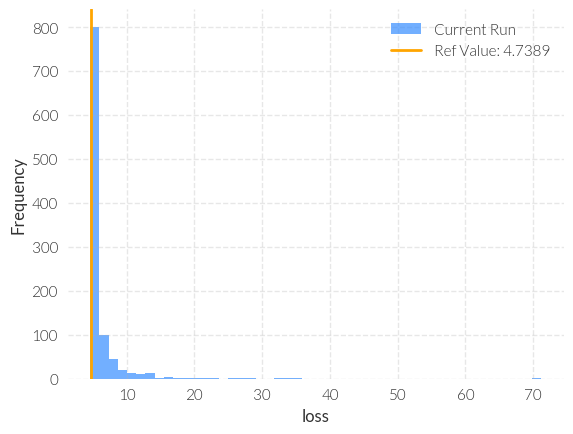

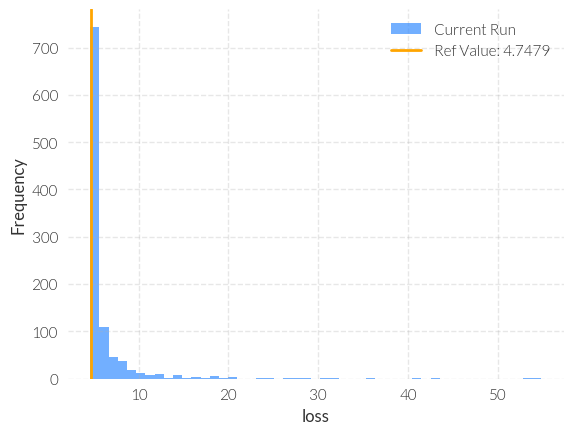

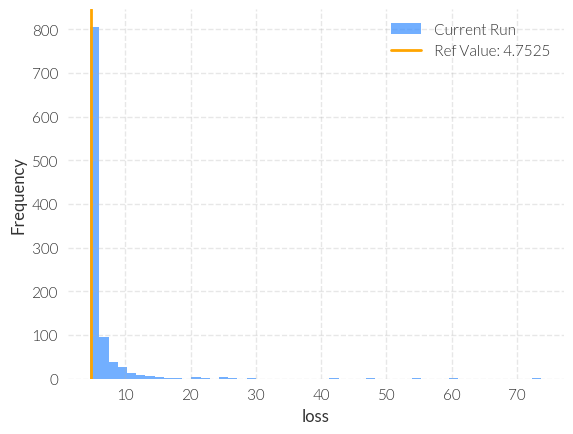

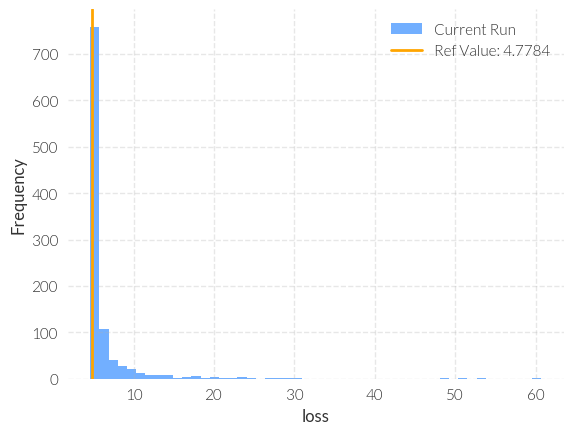

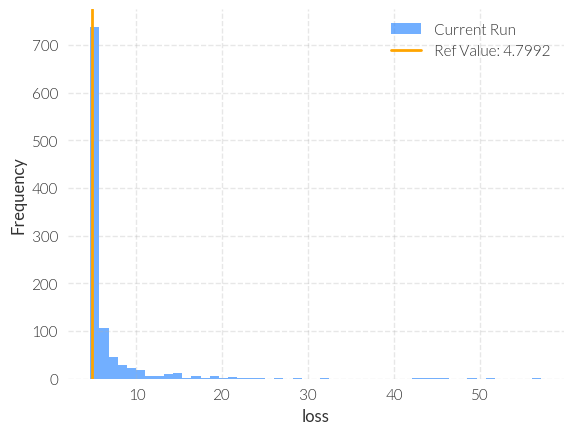

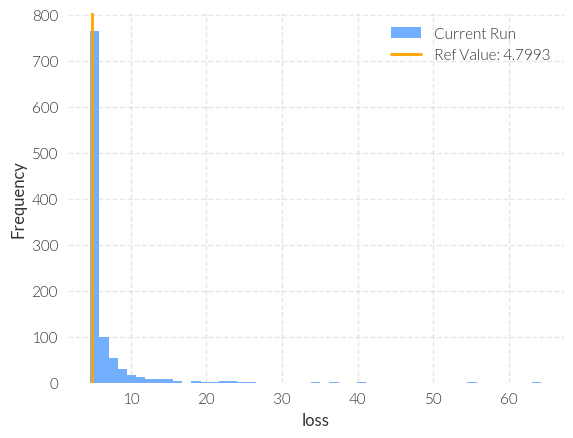

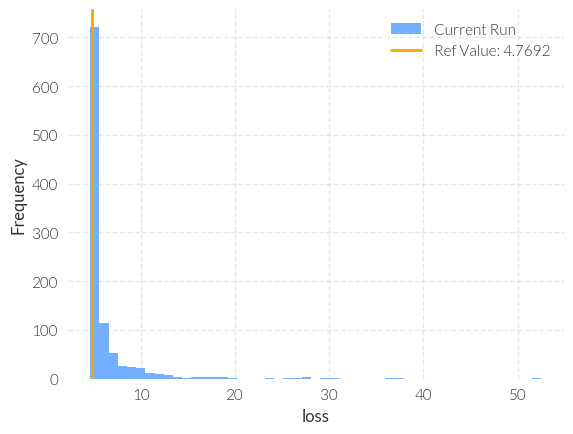

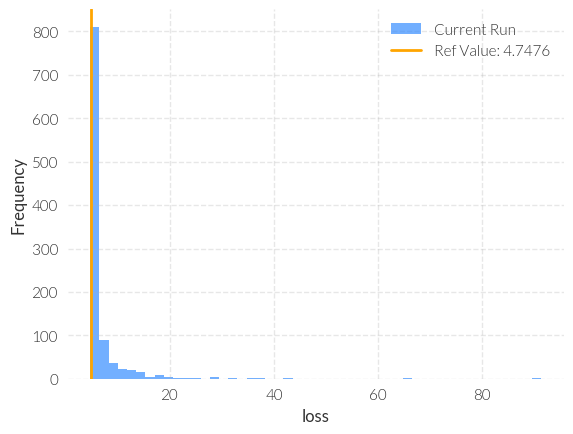

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# 変数設定（環境に合わせて適宜変更してください）
metric = "loss"
use_log_scale = False
num_bins = 50

# 前のイテレーションから値を引き継ぐための変数
stored_ref_value = None

for run_data in runs_data:
    path_eval = np.array(run_data["eval"]["path"][metric])
    
    # 配列が空の場合はスキップ
    if path_eval.size == 0:
        continue

    min_val = np.min(path_eval)
    max_val = np.max(path_eval)
    
    # 値が1種類（分散0）かどうかを判定
    is_single_value = (min_val == max_val)

    if is_single_value:
        # 値が1つの場合：その値を新しい基準線として保持し、次の分布グラフまでグラフ描画をスキップ
        # 次に is_single_value が True になるまで、この値が維持される
        stored_ref_value = min_val
        continue

    # 値が分布している場合：ヒストグラムを描画
    if use_log_scale:
        # 0以下の値が含まれる場合の対数計算エラー回避
        valid_min = max(min_val, 1e-10)
        bins = np.logspace(np.log10(valid_min), np.log10(max_val), num_bins)
    else:
        bins = np.linspace(min_val, max_val, num_bins)
        
    plt.hist(path_eval, bins=bins, alpha=0.7, label='Current Run')

    # 保持された値がある場合、垂直線を描画（リセットせず継続して表示）
    if stored_ref_value is not None:
        plt.axvline(
            x=stored_ref_value,
            color='orange',
            linestyle='-',
            linewidth=2,
            label=f'Ref Value: {stored_ref_value:.4f}'
        )
        # Note: 以前のコードにあった `stored_ref_value = None` を削除することで、
        # 次のシングルバリューが出るまで線を維持する

    if use_log_scale:
        plt.xscale('log')
    else:
        plt.xscale('linear')

    plt.xlabel(metric)
    plt.ylabel("Frequency")
    plt.legend()
    
    plt.show()

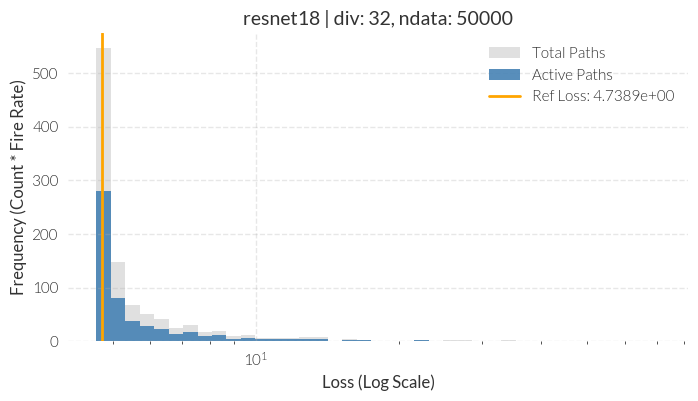

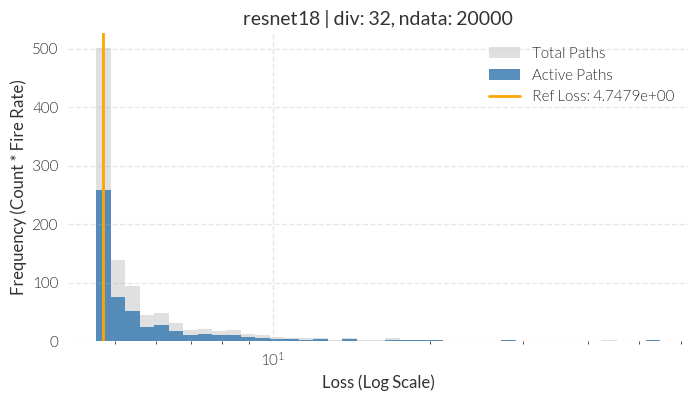

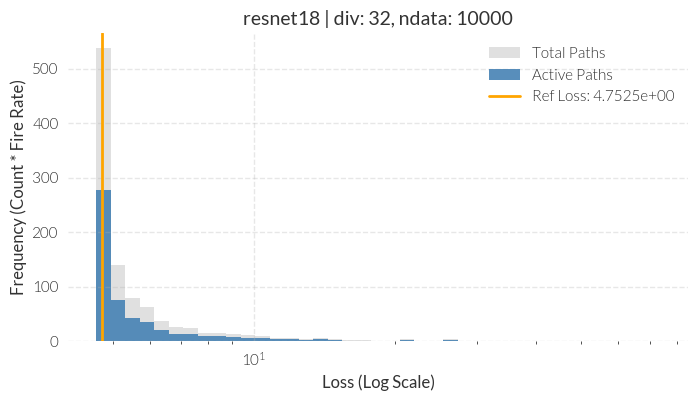

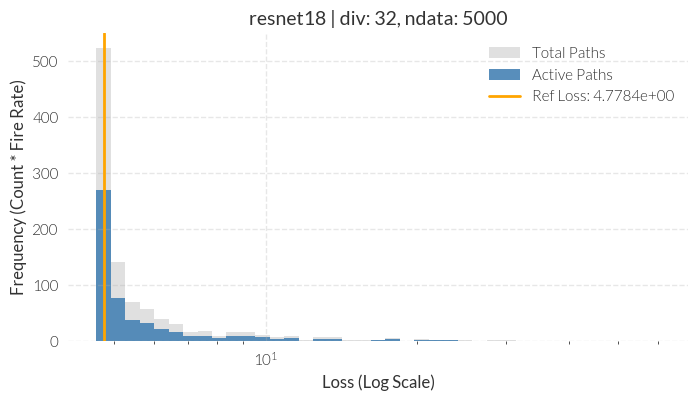

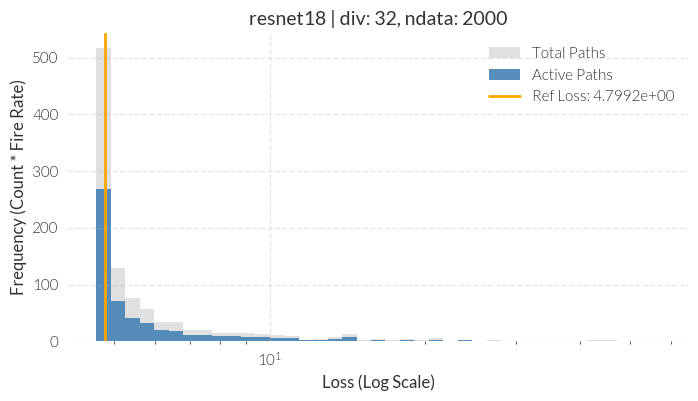

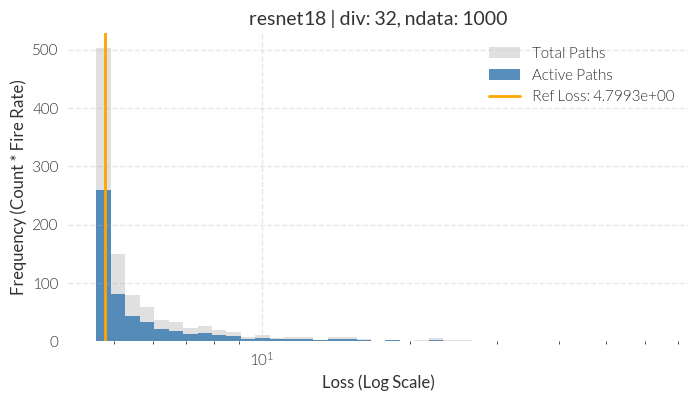

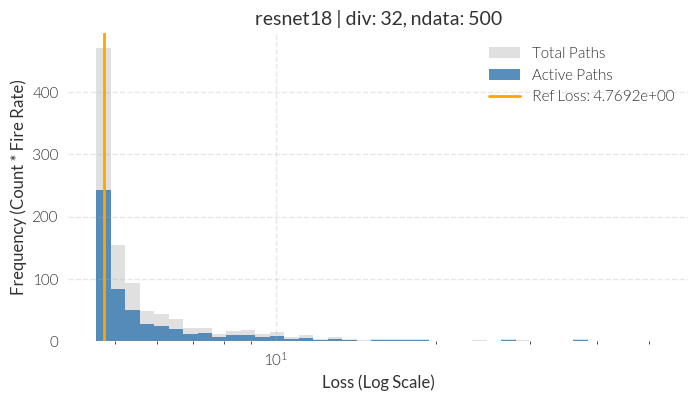

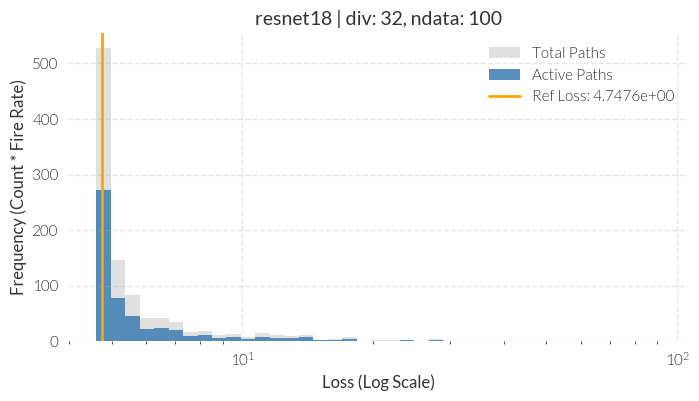

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# 前のイテレーションから値を引き継ぐための変数
stored_ref_value = None

for run_data in runs_data:
    # データの取得
    path_losses = np.array(run_data["eval"]["path"]["loss"])
    
    # 配列が空の場合はスキップ
    if path_losses.size == 0:
        continue

    # Fire Rate: (num_groups,)
    path_rates = np.array(run_data["activation_rate"]["path"])

    min_val = np.min(path_losses)
    max_val = np.max(path_losses)

    # 値が1種類（分散0）かどうかを判定
    is_single_value = (min_val == max_val)

    if is_single_value:
        # 値が1つの場合：その値を保持し、次の分布グラフまで描画をスキップ
        # 再度このブロックに入るまで値は維持される
        stored_ref_value = min_val
        continue

    # 以下、値が分布している場合の描画処理
    plt.figure(figsize=(8, 4))

    # ビンの設定（対数軸用）
    # 0以下の値が含まれる場合の対数計算エラー回避
    valid_min = max(min_val, 1e-8)
    bins = np.logspace(np.log10(valid_min), np.log10(max_val), 40)

    # 1. 全パス数の分布（薄い色で背景に表示）
    plt.hist(path_losses, bins=bins, color='lightgray', alpha=0.7, label='Total Paths')

    # 2. 発火率で重み付けした分布（濃い色で手前に表示）
    plt.hist(path_losses, bins=bins, weights=path_rates, color='steelblue', alpha=0.9, label='Active Paths')

    # 保持された値がある場合、垂直線を描画
    if stored_ref_value is not None:
        plt.axvline(
            x=stored_ref_value,
            color='orange',
            linestyle='-',
            linewidth=2,
            label=f'Ref Loss: {stored_ref_value:.4e}'
        )
        # 次の単一値が出るまで値を維持するため、リセットは行わない

    # 軸・ラベル設定
    plt.xscale('log')
    plt.xlabel("Loss (Log Scale)")
    plt.ylabel("Frequency (Count * Fire Rate)")

    # タイトル設定：モデル名に加え、divとtrain_ndataを表示
    model_arc = run_data.get('model_arc', 'Unknown')
    div_val = run_data.get('div', 'N/A')
    ndata_val = run_data.get('train_ndata', 'N/A')
    
    plt.title(f"{model_arc} | div: {div_val}, ndata: {ndata_val}")
    plt.legend()
    
    plt.show()

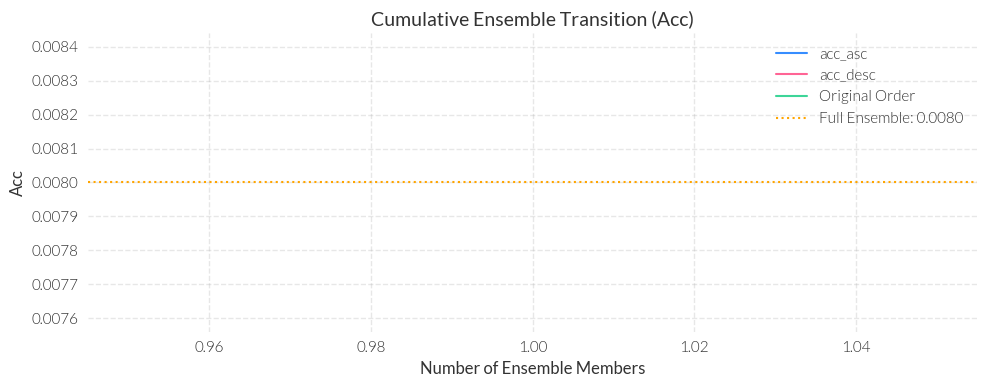

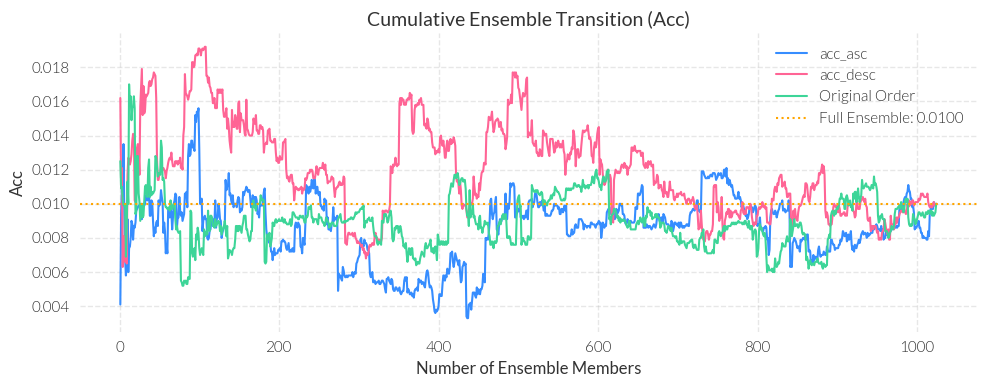

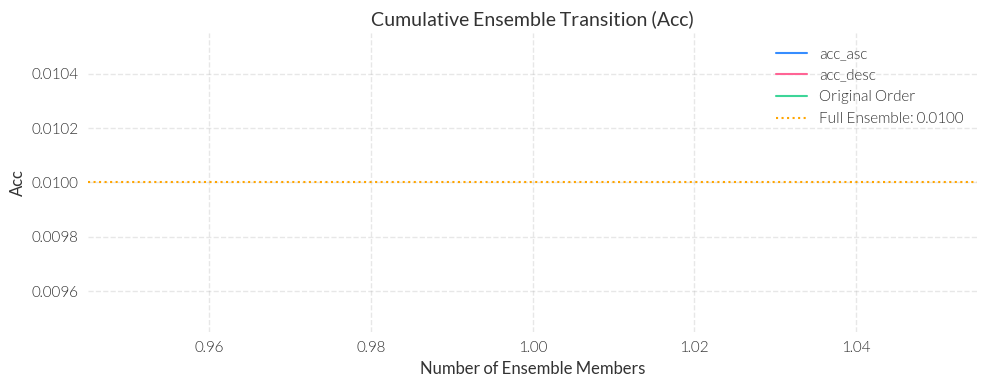

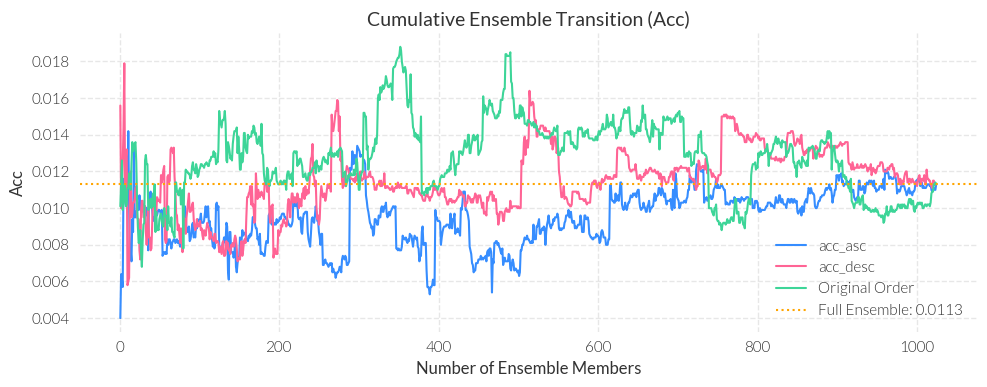

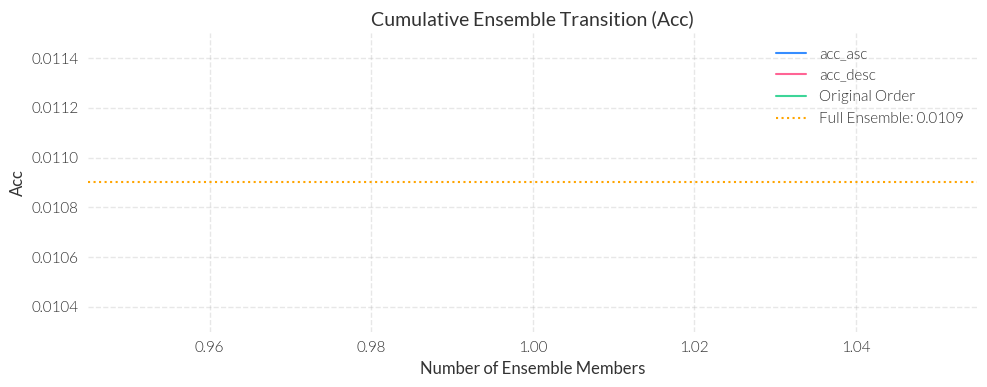

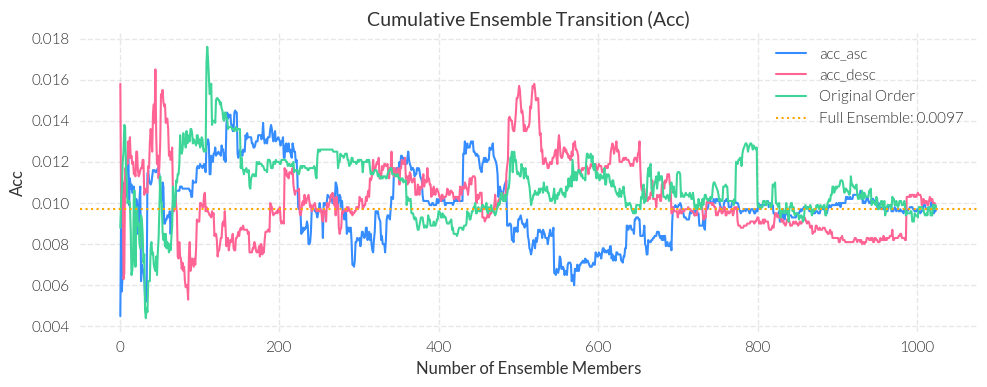

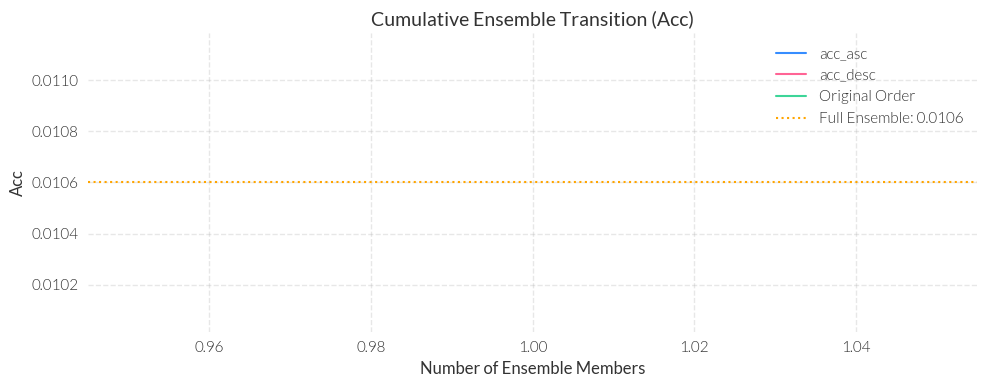

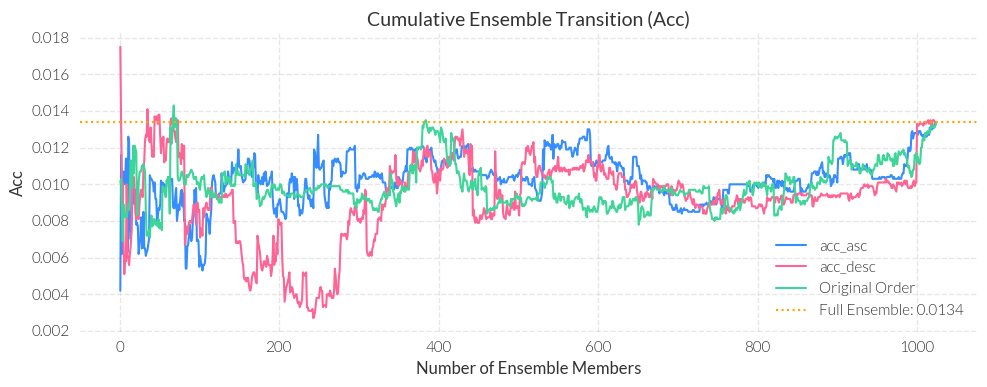

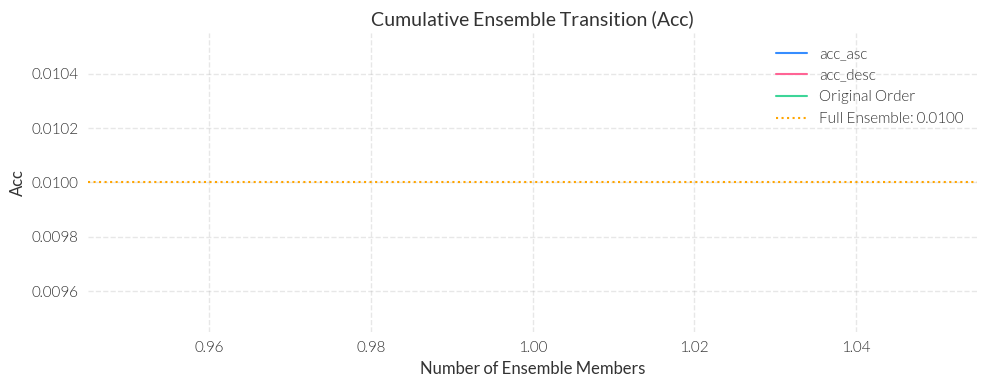

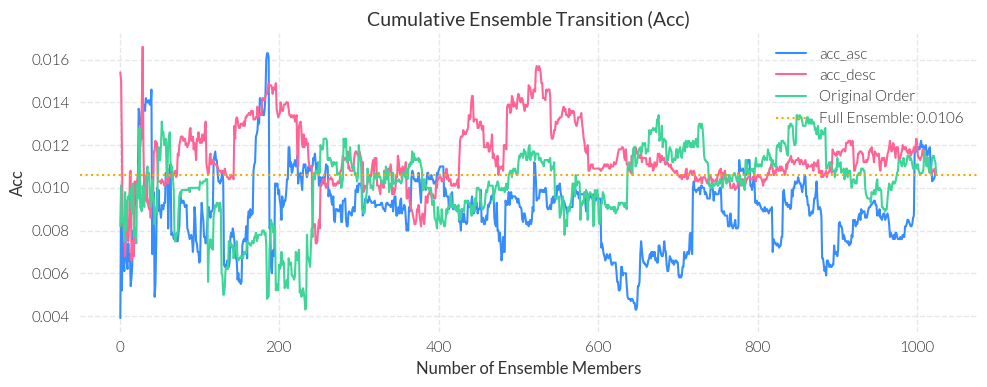

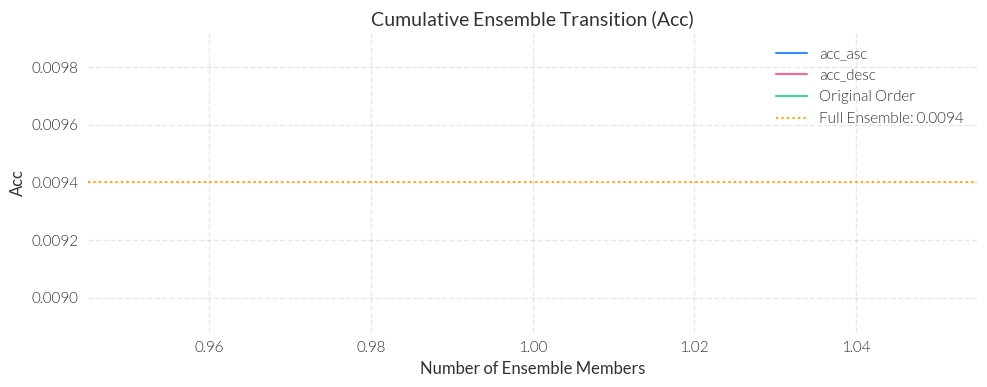

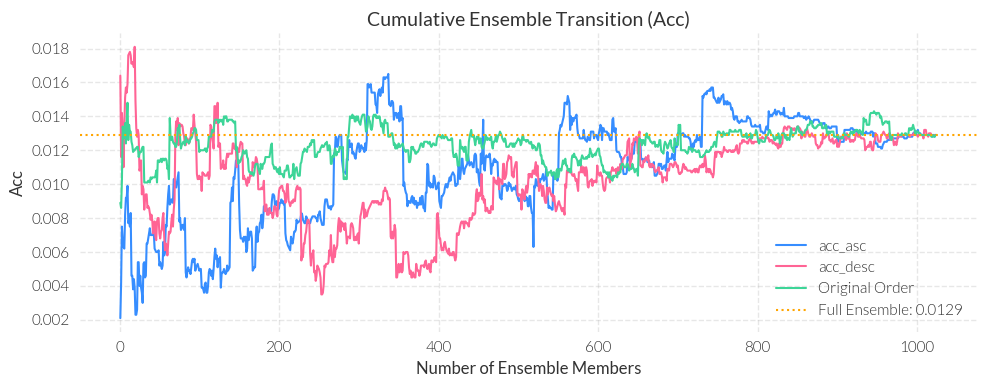

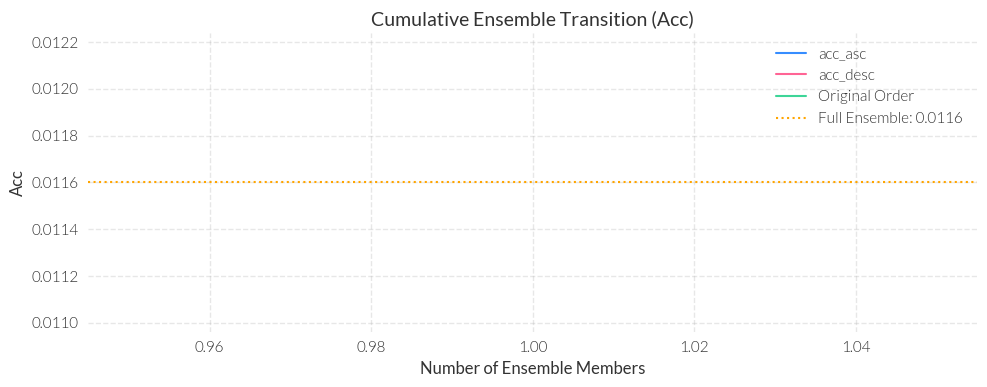

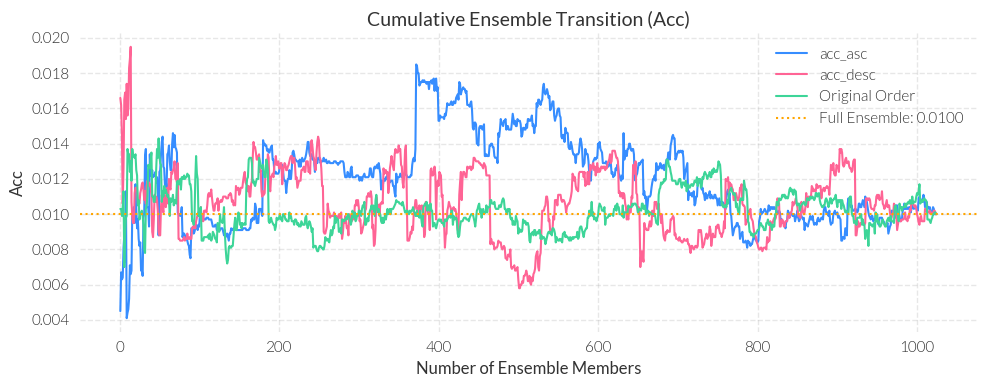

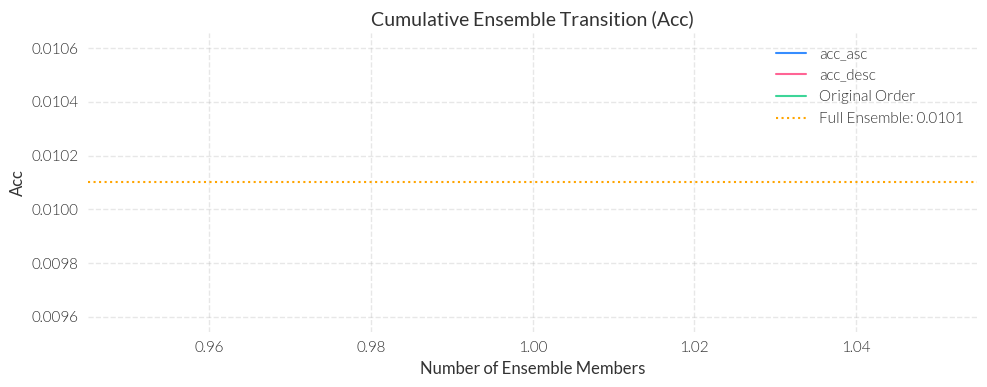

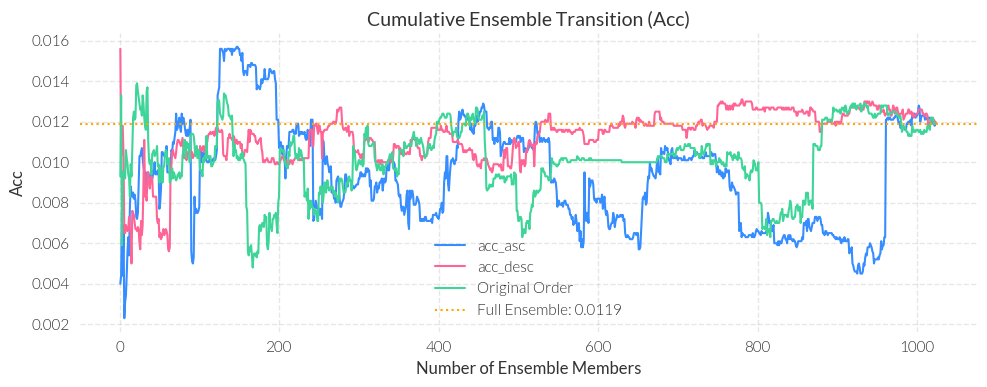

In [8]:
import matplotlib.pyplot as plt
import numpy as np

for run_data in runs_data:
    # --- 変数設定（環境に合わせて適宜変更してください） ---
    # results: Analyzer.flow() の実行結果辞書をここに代入している前提
    # metric: "loss" または "acc"
    target_metric = "acc"

    # --- データ抽出 ---
    eval_res = run_data.get("eval", {})
    cumulative_data = eval_res.get("cumulative", {})
    ens_res = eval_res.get("ens", {})
    
    cumulative_data = run_data["eval"]["cumulative"]
    
    cumulative_data = { k: v for k, v in cumulative_data.items() if "acc" in k or "original" in k }

    if not cumulative_data:
        print("表示可能な累積データ (cumulative data) がありません。")
        print("Analyzer実行時に cumulative_modes=['original', 'asc', ...] が指定されているか確認してください。")

    else:
        # --- 描画設定 ---
        plt.figure(figsize=(10, 4))

        # --- 各モードのプロット ---
        # 辞書順だと色がランダムになる可能性があるため、キーをソートして処理順を固定
        for mode in sorted(cumulative_data.keys()):
            data_dict = cumulative_data[mode]
            
            # 指定された指標が存在するか確認
            if target_metric not in data_dict:
                continue
            
            y_values = np.array(data_dict[target_metric])
            x_values = np.arange(1, len(y_values) + 1) # メンバ数 (1 start)

            if y_values.size == 0:
                continue

            # ラベル設定のみ行い、色やスタイルはMatplotlibのデフォルトに任せる
            if mode == 'asc':
                label_text = 'Ascending (Best First)'
            elif mode == 'desc':
                label_text = 'Descending (Worst First)'
            elif mode == 'original' or mode == 'ordinal':
                label_text = 'Original Order'
            else:
                label_text = mode

            plt.plot(x_values, y_values, label=label_text)

        # --- 参照値（Full Ensemble）の描画 ---
        # 比較用のため、最低限の区別として点線を使用
        if target_metric in ens_res:
            ref_value = ens_res[target_metric]
            plt.axhline(
                y=ref_value,
                color='orange', # 参照線だと分かるように色のみ維持（必要なければ削除可）
                linestyle=':',
                label=f'Full Ensemble: {ref_value:.4f}'
            )

        # --- グラフの装飾 ---
        plt.xlabel("Number of Ensemble Members")
        plt.ylabel(target_metric.capitalize())
        plt.title(f"Cumulative Ensemble Transition ({target_metric.capitalize()})")
        
        
        plt.legend()
        plt.tight_layout()
        
        plt.show()

In [9]:
for run_data in runs_data:
    # データの取得
    print(f"{run_data["train_ndata"]}, div={run_data["div"]}")
    path_losses = np.array(run_data["eval"]["oracle"])
    
    print(path_losses.min())

50000, div=1
{'acc': 0.00800000037997961, 'loss': 4.738860607147217}
50000, div=32
{'acc': 1.0, 'loss': 0.8993518352508545}
20000, div=1
{'acc': 0.009999999776482582, 'loss': 4.747865200042725}
20000, div=32
{'acc': 1.0, 'loss': 0.8044968247413635}
10000, div=1
{'acc': 0.010900000110268593, 'loss': 4.752506732940674}
10000, div=32
{'acc': 1.0, 'loss': 0.8471797108650208}
5000, div=1
{'acc': 0.010599999688565731, 'loss': 4.778372764587402}
5000, div=32
{'acc': 1.0, 'loss': 0.7780578136444092}
2000, div=1
{'acc': 0.009999999776482582, 'loss': 4.799193382263184}
2000, div=32
{'acc': 1.0, 'loss': 0.8912377953529358}
1000, div=1
{'acc': 0.009399999864399433, 'loss': 4.799277305603027}
1000, div=32
{'acc': 1.0, 'loss': 0.8028674721717834}
500, div=1
{'acc': 0.011599999852478504, 'loss': 4.769174575805664}
500, div=32
{'acc': 1.0, 'loss': 0.8278874754905701}
100, div=1
{'acc': 0.010099999606609344, 'loss': 4.747562885284424}
100, div=32
{'acc': 1.0, 'loss': 0.796444833278656}


In [10]:
import numpy as np

for run_data in runs_data:
    print(f"ipc={run_data["train_ndata"]//100}, r={run_data["div"]}")
    ind = "oracle"
    pathinfo_l = np.array(run_data["eval"][ind]["acc"])
    print(f"{ind}: {pathinfo_l}")
    ind = "ens"
    pathinfo_l = np.array(run_data["eval"][ind]["acc"])
    print(f"{ind}: {pathinfo_l}")
    
    # print(path_losses.min())

ipc=500, r=1
oracle: 0.00800000037997961
ens: 0.00800000037997961
ipc=500, r=32
oracle: 1.0
ens: 0.009999999776482582
ipc=200, r=1
oracle: 0.009999999776482582
ens: 0.009999999776482582
ipc=200, r=32
oracle: 1.0
ens: 0.011300000362098217
ipc=100, r=1
oracle: 0.010900000110268593
ens: 0.010900000110268593
ipc=100, r=32
oracle: 1.0
ens: 0.009700000286102295
ipc=50, r=1
oracle: 0.010599999688565731
ens: 0.010599999688565731
ipc=50, r=32
oracle: 1.0
ens: 0.013399999588727951
ipc=20, r=1
oracle: 0.009999999776482582
ens: 0.009999999776482582
ipc=20, r=32
oracle: 1.0
ens: 0.010599999688565731
ipc=10, r=1
oracle: 0.009399999864399433
ens: 0.009399999864399433
ipc=10, r=32
oracle: 1.0
ens: 0.012900000438094139
ipc=5, r=1
oracle: 0.011599999852478504
ens: 0.011599999852478504
ipc=5, r=32
oracle: 1.0
ens: 0.009999999776482582
ipc=1, r=1
oracle: 0.010099999606609344
ens: 0.010099999606609344
ipc=1, r=32
oracle: 1.0
ens: 0.011900000274181366
